# **Box Plots**


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [119]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-03-16 07:05:31--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.45.118.108
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.45.118.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite.1’

survey-results-publ 100%[===================>] 201.62M  47.8MB/s    in 4.5s    

2026-03-16 07:05:36 (44.5 MB/s) - ‘survey-results-public.sqlite.1’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [120]:
!pip install pandas

In [121]:
!pip install matplotlib

In [122]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [123]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [124]:
QUERY = """
SELECT name as Table_Name
FROM sqlite_master
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [125]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


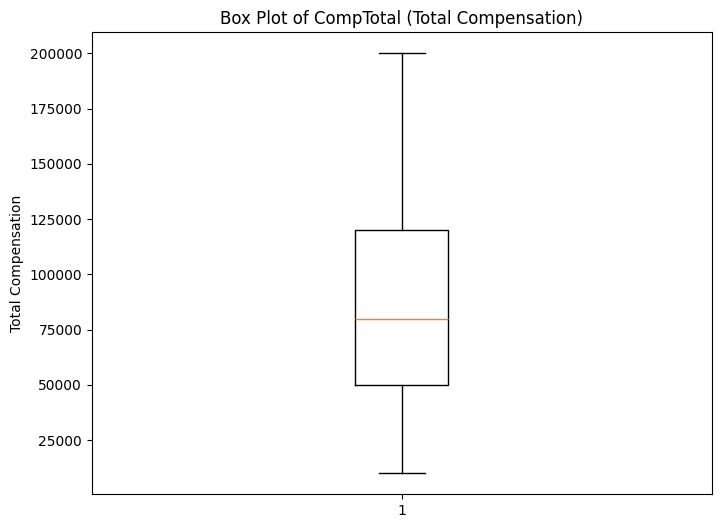

In [126]:
QUERY = "SELECT CompTotal FROM main"
df_comptotal = pd.read_sql_query(QUERY, conn)

# Filter out NULL values from CompTotal and values outside the range 10,000 to 200,000
df_comptotal = df_comptotal.dropna(subset=['CompTotal'])
df_comptotal = df_comptotal[(df_comptotal['CompTotal'] >= 10000) & (df_comptotal['CompTotal'] <= 200000)]

plt.figure(figsize=(8, 6))
plt.boxplot(df_comptotal['CompTotal'])
plt.title('Box Plot of CompTotal (Total Compensation)')
plt.ylabel('Total Compensation')
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


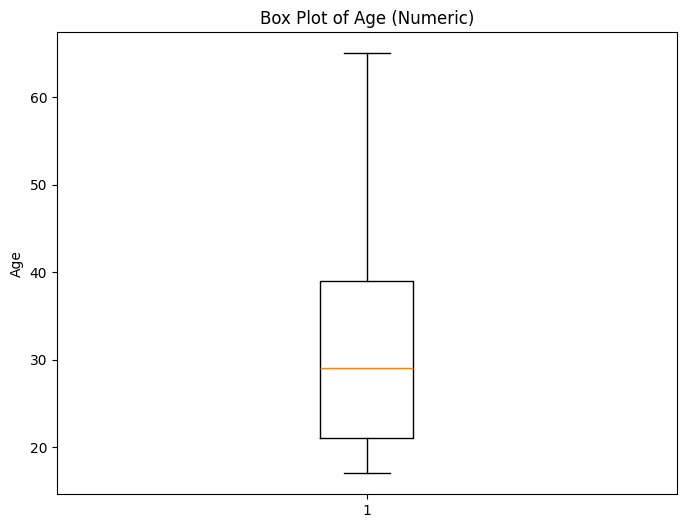

In [127]:
QUERY = "SELECT Age FROM main"
df_age = pd.read_sql_query(QUERY, conn)

# Define a mapping for age groups to numerical values
age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 65,
    'Prefer not to say': None  # Or exclude if preferred
}

# Convert 'Age' column to numeric using the mapping
df_age['AgeNumeric'] = df_age['Age'].map(age_map)

# Filter out rows where AgeNumeric is NaN (e.g., 'Prefer not to say')
df_age_numeric = df_age.dropna(subset=['AgeNumeric'])

plt.figure(figsize=(8, 6))
plt.boxplot(df_age_numeric['AgeNumeric'])
plt.title('Box Plot of Age (Numeric)')
plt.ylabel('Age')
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


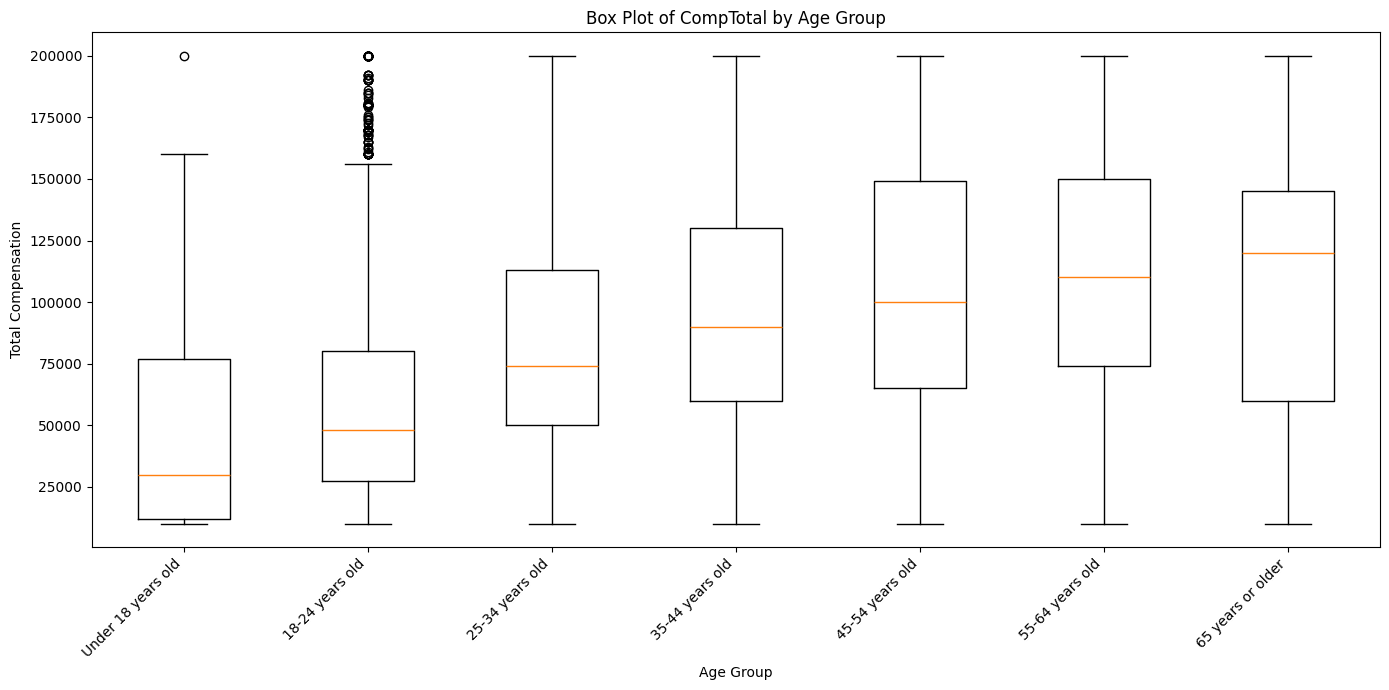

In [129]:
QUERY = "SELECT Age, CompTotal FROM main"
df_age_comptotal = pd.read_sql_query(QUERY, conn)

# Filter out NULL values from CompTotal and Age
df_age_comptotal = df_age_comptotal.dropna(subset=['CompTotal', 'Age'])

# Filter out CompTotal values outside the range 10,000 to 200,000
df_age_comptotal = df_age_comptotal[(df_age_comptotal['CompTotal'] >= 10000) & (df_age_comptotal['CompTotal'] <= 200000)]

# Filter out 'Prefer not to say' from Age
df_age_comptotal = df_age_comptotal[df_age_comptotal['Age'] != 'Prefer not to say']

# Define the order of age groups for consistent plotting
age_groups_order = ['Under 18 years old', '18-24 years old', '25-34 years old', '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older']

# Prepare data for box plot, ensuring correct order
data_to_plot = [df_age_comptotal[df_age_comptotal['Age'] == age_group]['CompTotal'].values for age_group in age_groups_order]

plt.figure(figsize=(14, 7))
plt.boxplot(data_to_plot, tick_labels=age_groups_order) # Changed 'labels' to 'tick_labels'
plt.title('Box Plot of CompTotal by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Compensation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


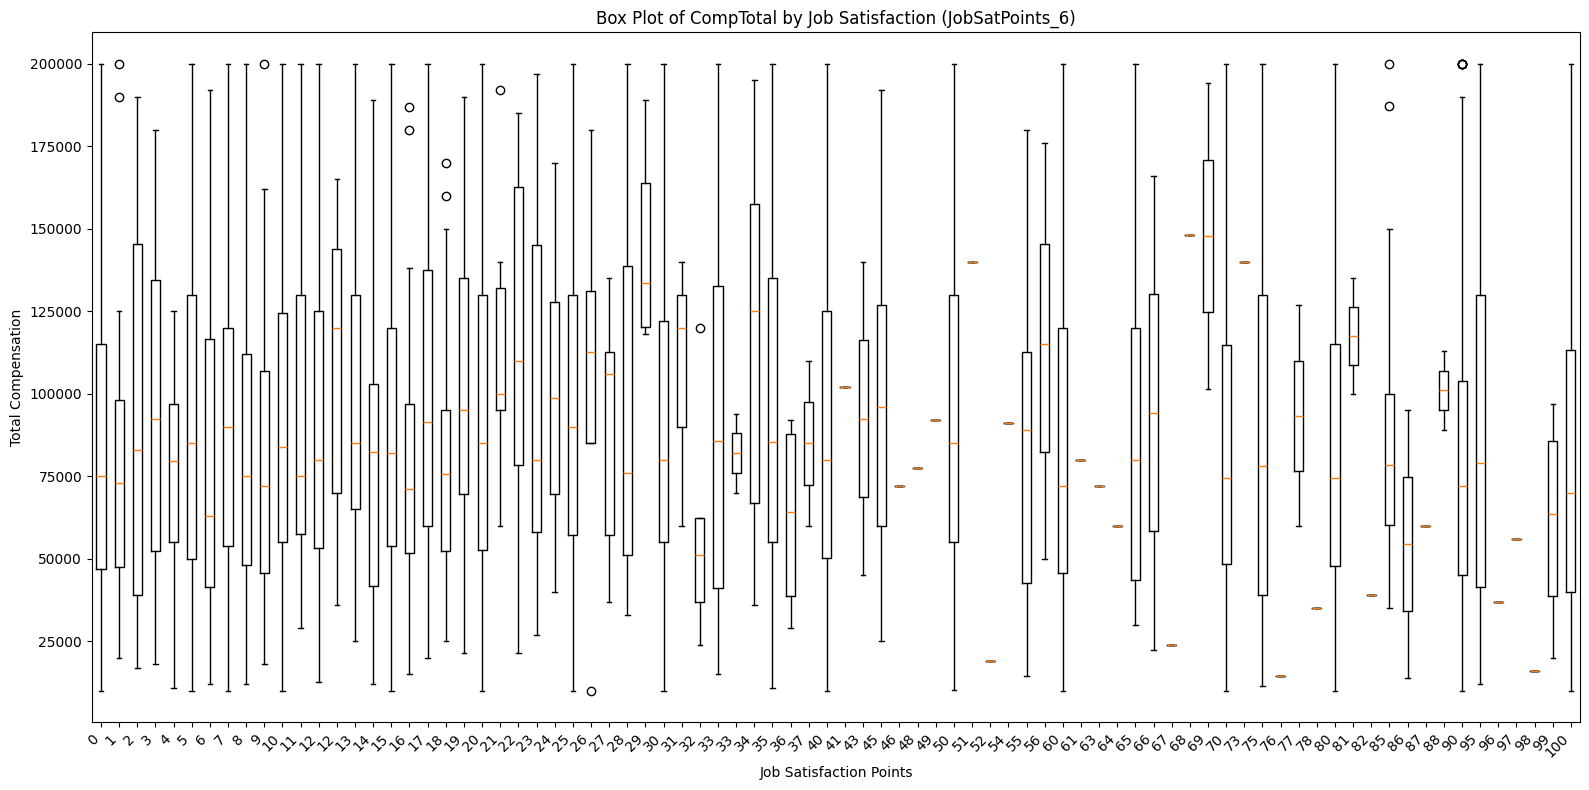

In [130]:
QUERY = "SELECT JobSatPoints_6, CompTotal FROM main"
df_jobsat_comptotal = pd.read_sql_query(QUERY, conn)

# Filter out NULL values from JobSatPoints_6 and CompTotal
df_jobsat_comptotal = df_jobsat_comptotal.dropna(subset=['JobSatPoints_6', 'CompTotal'])

# Filter out CompTotal values outside the range 10,000 to 200,000
df_jobsat_comptotal = df_jobsat_comptotal[(df_jobsat_comptotal['CompTotal'] >= 10000) & (df_jobsat_comptotal['CompTotal'] <= 200000)]

# Get unique job satisfaction points and sort them
jobsat_points_order = sorted(df_jobsat_comptotal['JobSatPoints_6'].unique())

# Prepare data for box plot, ensuring correct order of job satisfaction points
data_to_plot_jobsat = [df_jobsat_comptotal[df_jobsat_comptotal['JobSatPoints_6'] == point]['CompTotal'].values for point in jobsat_points_order]

plt.figure(figsize=(16, 8))
plt.boxplot(data_to_plot_jobsat, tick_labels=[str(int(p)) for p in jobsat_points_order])
plt.title('Box Plot of CompTotal by Job Satisfaction (JobSatPoints_6)')
plt.xlabel('Job Satisfaction Points')
plt.ylabel('Total Compensation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


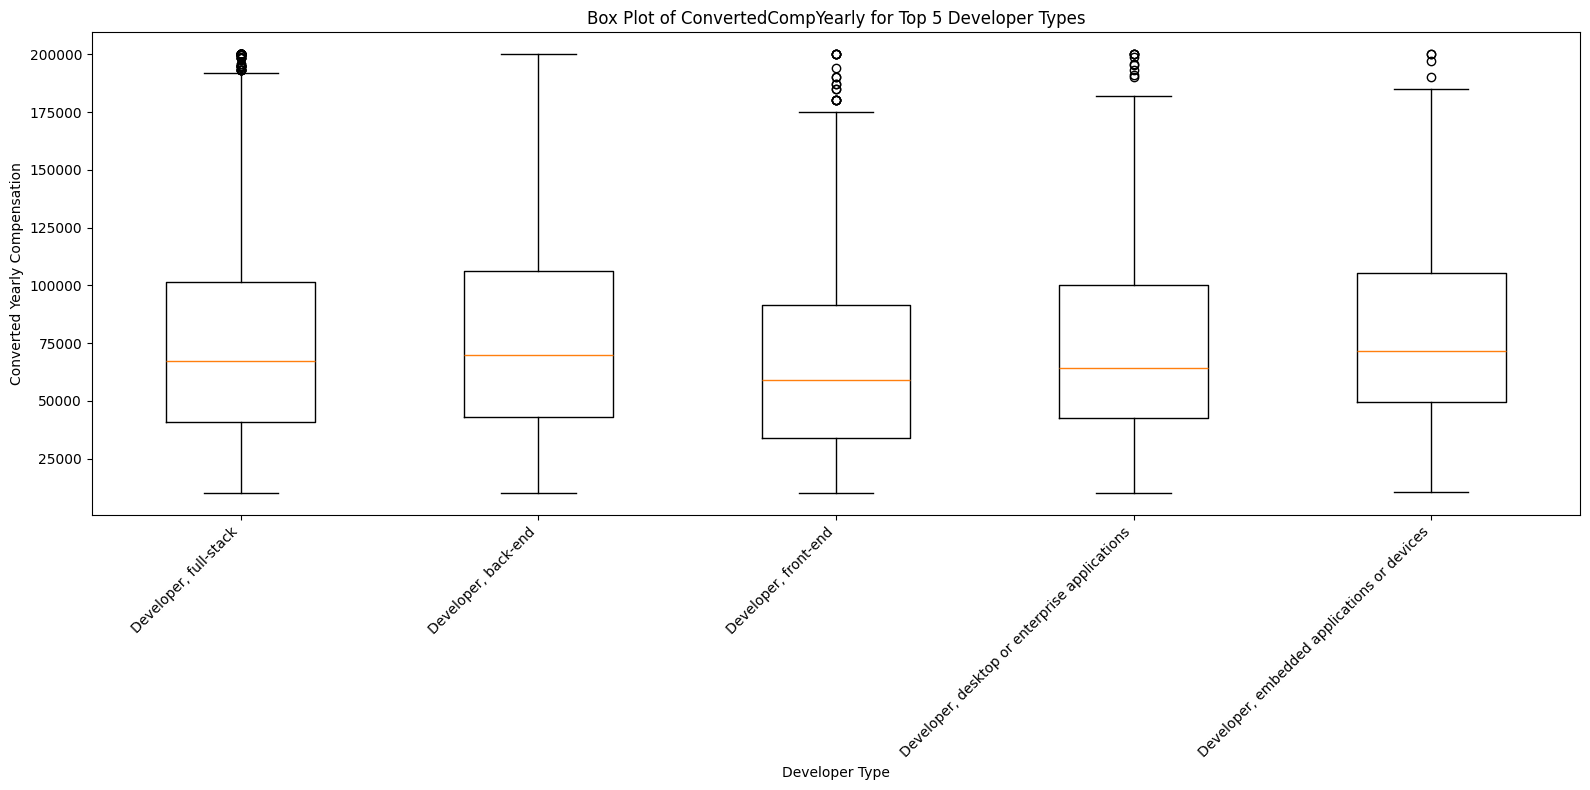

In [131]:
# Task 3.1: Box Plot of ConvertedCompYearly for the Top 5 Developer Types

# Query data for DevType and ConvertedCompYearly
QUERY = "SELECT DevType, ConvertedCompYearly FROM main"
df_devtype_comp = pd.read_sql_query(QUERY, conn)

# Drop rows with any NaN values in the relevant columns
df_devtype_comp.dropna(subset=['DevType', 'ConvertedCompYearly'], inplace=True)

# Filter ConvertedCompYearly for reasonable ranges (e.g., between 10,000 and 200,000)
df_devtype_comp = df_devtype_comp[(df_devtype_comp['ConvertedCompYearly'] >= 10000) & (df_devtype_comp['ConvertedCompYearly'] <= 200000)]

# Clean up DevType strings: remove brackets and strip whitespace
df_devtype_comp['DevType'] = df_devtype_comp['DevType'].astype(str).str.replace(r'\[|\]', '', regex=True).str.strip()

# Calculate the top 5 developer types based on cleaned data
top_5_devtypes = df_devtype_comp['DevType'].value_counts().nlargest(5).index.tolist()

# Filter the DataFrame to include only the top 5 developer types
df_top5_devtypes_filtered = df_devtype_comp[df_devtype_comp['DevType'].isin(top_5_devtypes)]

# Prepare data for box plot, ensuring correct order of developer types
data_to_plot_devtype = [df_top5_devtypes_filtered[df_top5_devtypes_filtered['DevType'] == devtype]['ConvertedCompYearly'].values for devtype in top_5_devtypes]

plt.figure(figsize=(16, 8))
plt.boxplot(data_to_plot_devtype, tick_labels=top_5_devtypes)
plt.title('Box Plot of ConvertedCompYearly for Top 5 Developer Types')
plt.xlabel('Developer Type')
plt.ylabel('Converted Yearly Compensation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


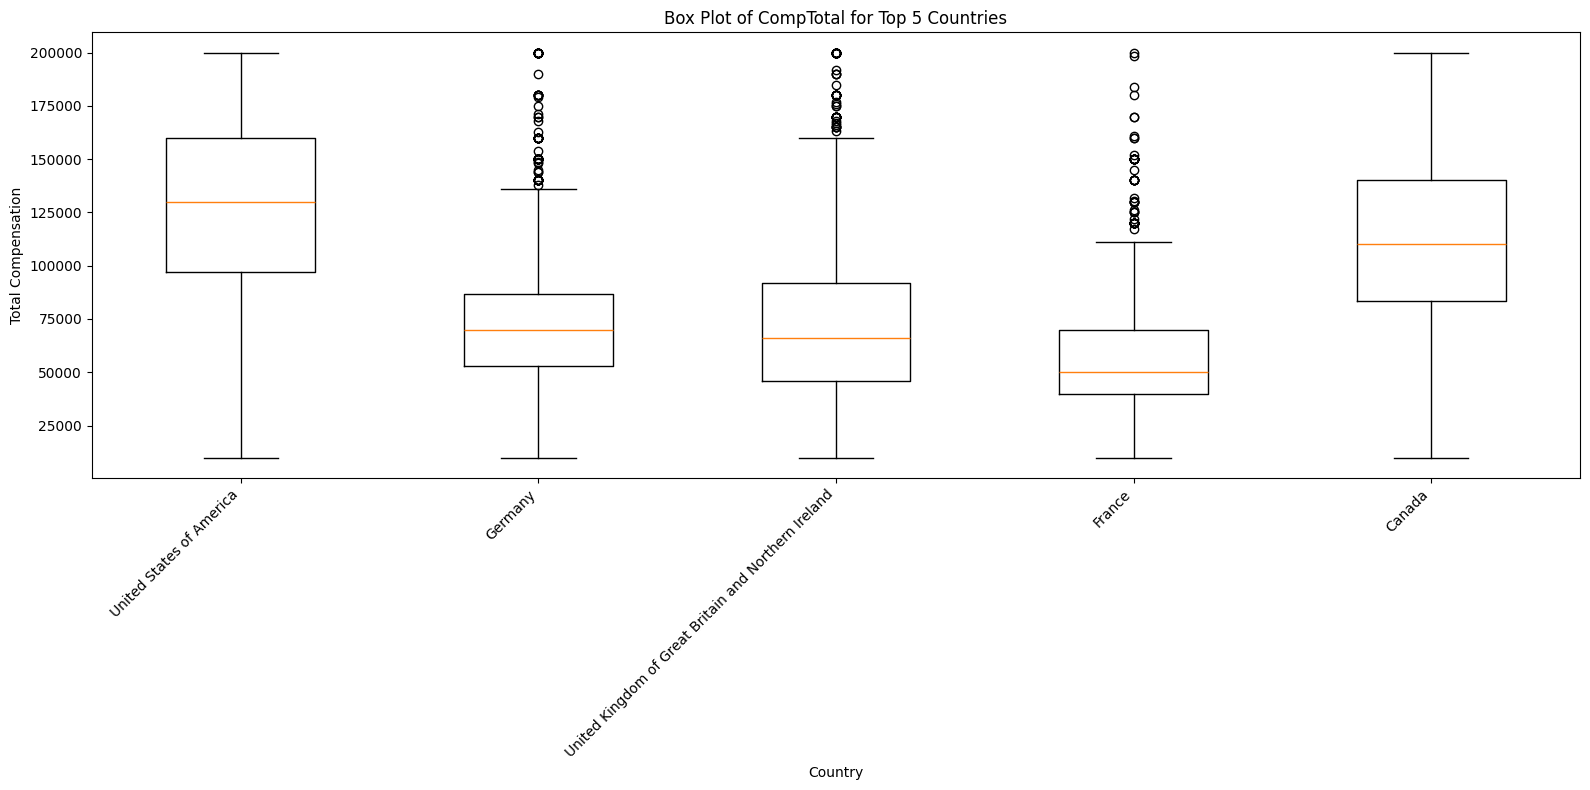

In [132]:
# Task 3.2: Box Plot of CompTotal for the Top 5 Countries

# Query data for Country and CompTotal
QUERY = "SELECT Country, CompTotal FROM main"
df_country_comptotal = pd.read_sql_query(QUERY, conn)

# Drop rows with any NaN values in the relevant columns
df_country_comptotal.dropna(subset=['Country', 'CompTotal'], inplace=True)

# Filter CompTotal values outside the range 10,000 to 200,000
df_country_comptotal = df_country_comptotal[(df_country_comptotal['CompTotal'] >= 10000) & (df_country_comptotal['CompTotal'] <= 200000)]

# Calculate the top 5 countries based on the number of respondents
top_5_countries = df_country_comptotal['Country'].value_counts().nlargest(5).index.tolist()

# Filter the DataFrame to include only the top 5 countries
df_top5_countries_filtered = df_country_comptotal[df_country_comptotal['Country'].isin(top_5_countries)]

# Prepare data for box plot, ensuring correct order of countries
data_to_plot_country = [df_top5_countries_filtered[df_top5_countries_filtered['Country'] == country]['CompTotal'].values for country in top_5_countries]

plt.figure(figsize=(16, 8))
plt.boxplot(data_to_plot_country, tick_labels=top_5_countries)
plt.title('Box Plot of CompTotal for Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('Total Compensation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


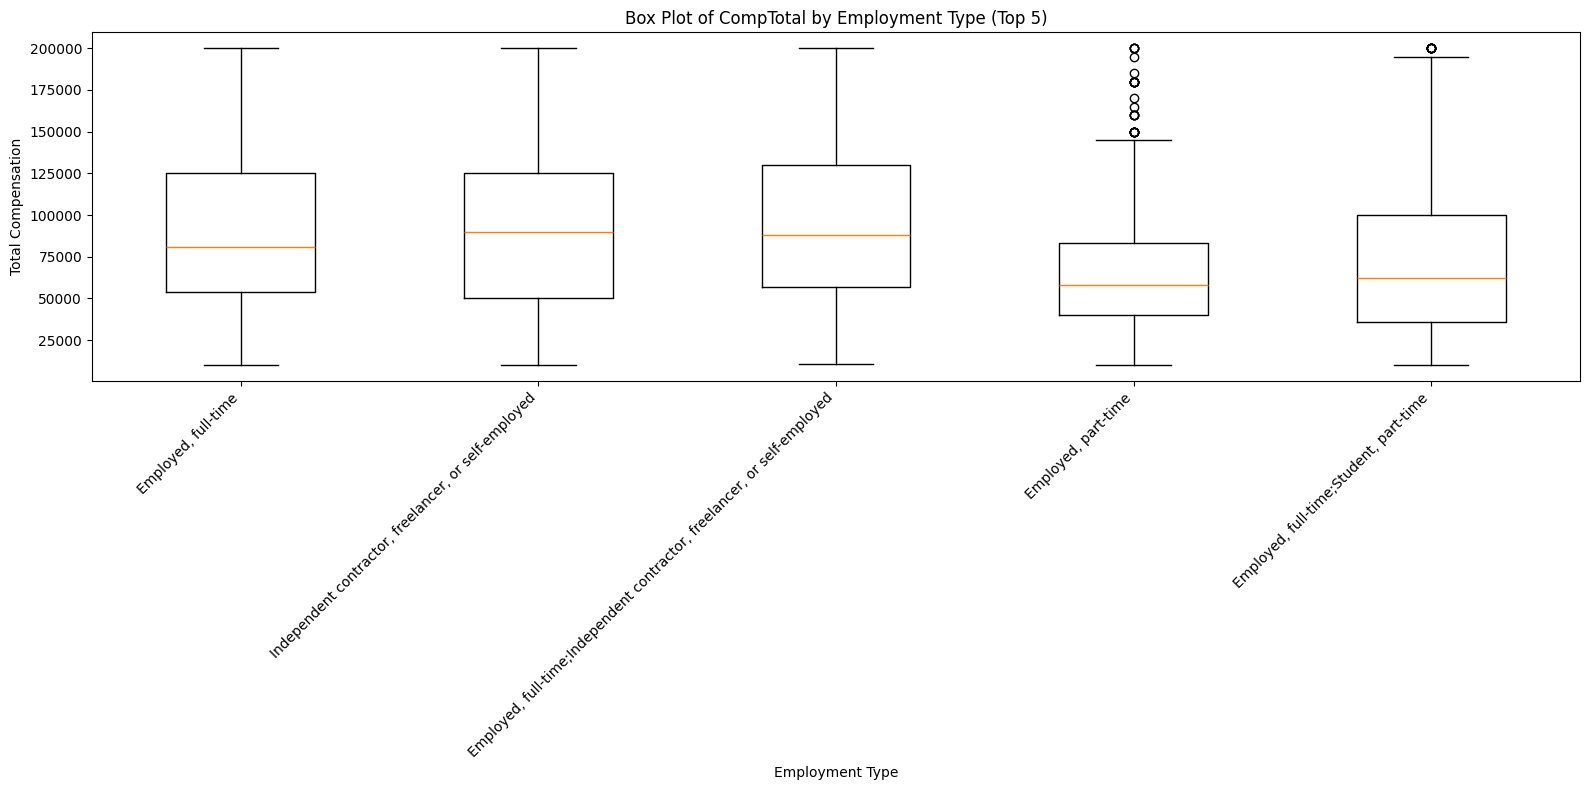

In [133]:
# Task 4.1: Box Plot of CompTotal Across Employment Types

# Query data for Employment and CompTotal
QUERY = "SELECT Employment, CompTotal FROM main"
df_employment_comptotal = pd.read_sql_query(QUERY, conn)

# Drop rows with any NaN values in the relevant columns
df_employment_comptotal.dropna(subset=['Employment', 'CompTotal'], inplace=True)

# Filter CompTotal values outside the range 10,000 to 200,000
df_employment_comptotal = df_employment_comptotal[(df_employment_comptotal['CompTotal'] >= 10000) & (df_employment_comptotal['CompTotal'] <= 200000)]

# Calculate the top 5 employment types based on the number of respondents
top_5_employment_types = df_employment_comptotal['Employment'].value_counts().nlargest(5).index.tolist()

# Filter the DataFrame to include only the top 5 employment types
df_top5_employment_filtered = df_employment_comptotal[df_employment_comptotal['Employment'].isin(top_5_employment_types)]

# Prepare data for box plot, ensuring correct order of employment types
data_to_plot_employment = [df_top5_employment_filtered[df_top5_employment_filtered['Employment'] == etype]['CompTotal'].values for etype in top_5_employment_types]

plt.figure(figsize=(16, 8))
plt.boxplot(data_to_plot_employment, tick_labels=top_5_employment_types)
plt.title('Box Plot of CompTotal by Employment Type (Top 5)')
plt.xlabel('Employment Type')
plt.ylabel('Total Compensation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


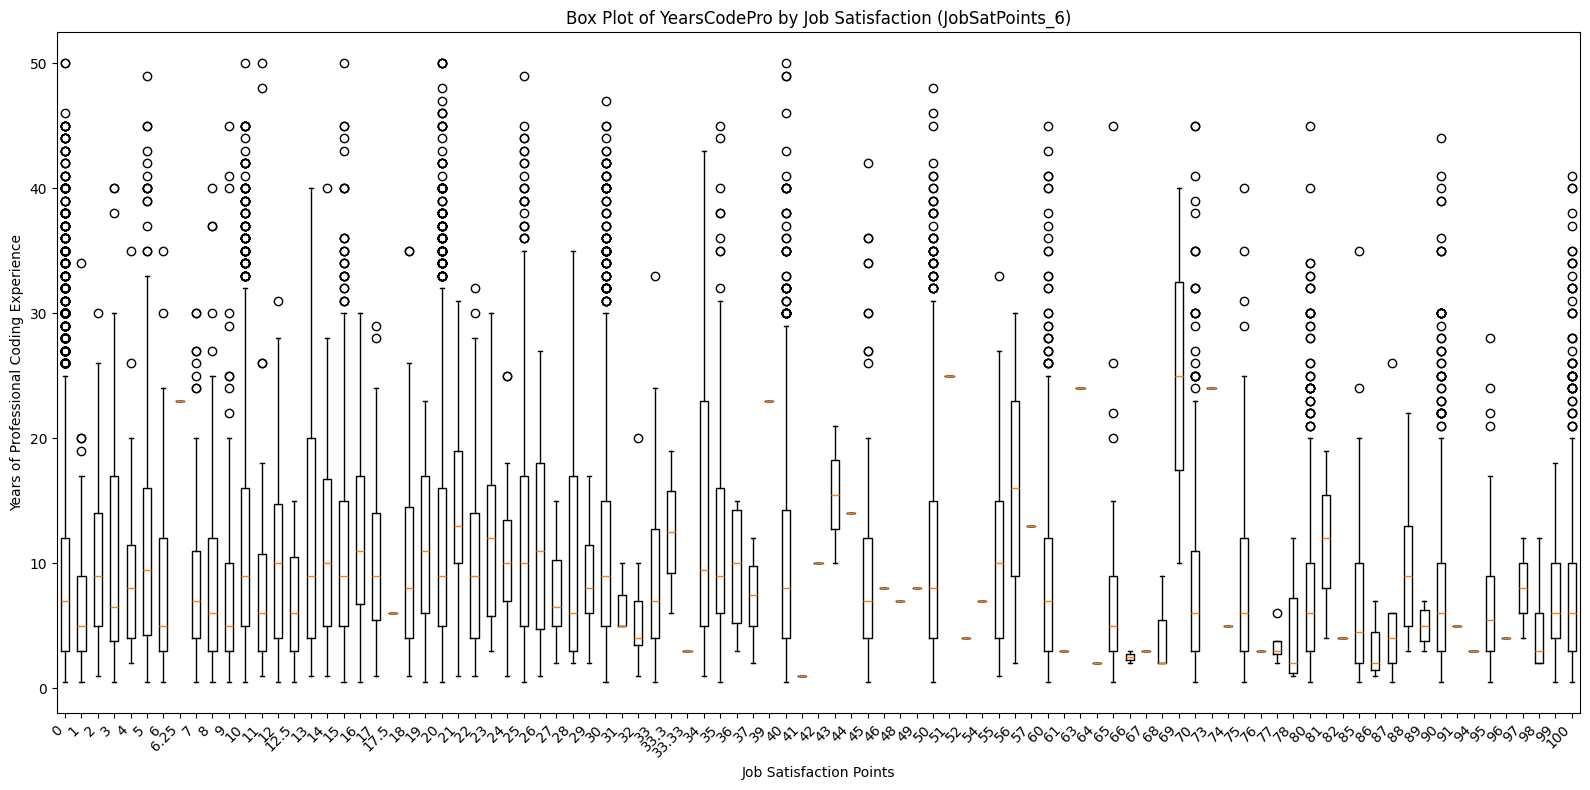

In [134]:
QUERY = "SELECT YearsCodePro, JobSatPoints_6 FROM main"
df_jobsat_yearscodepro = pd.read_sql_query(QUERY, conn)

# Drop rows with any NaN values in the relevant columns
df_jobsat_yearscodepro.dropna(subset=['YearsCodePro', 'JobSatPoints_6'], inplace=True)

# Convert 'YearsCodePro' to numeric, handling 'More than 50 years' and 'Less than 1 year'
df_jobsat_yearscodepro['YearsCodePro'] = df_jobsat_yearscodepro['YearsCodePro'].replace('More than 50 years', '50')
df_jobsat_yearscodepro['YearsCodePro'] = df_jobsat_yearscodepro['YearsCodePro'].replace('Less than 1 year', '0.5')
df_jobsat_yearscodepro['YearsCodePro'] = pd.to_numeric(df_jobsat_yearscodepro['YearsCodePro'])

# Filter out potential outliers for YearsCodePro (e.g., values > 50, which are already handled by conversion, or negative values)
df_jobsat_yearscodepro = df_jobsat_yearscodepro[df_jobsat_yearscodepro['YearsCodePro'] >= 0]

# Get unique job satisfaction points and sort them for consistent plotting
jobsat_points_order = sorted(df_jobsat_yearscodepro['JobSatPoints_6'].unique())

# Prepare data for box plot, ensuring correct order of job satisfaction points
data_to_plot_yearscodepro = [df_jobsat_yearscodepro[df_jobsat_yearscodepro['JobSatPoints_6'] == point]['YearsCodePro'].values for point in jobsat_points_order]

plt.figure(figsize=(16, 8))
plt.boxplot(data_to_plot_yearscodepro, tick_labels=[str(int(p)) if p == int(p) else str(p) for p in jobsat_points_order])
plt.title('Box Plot of YearsCodePro by Job Satisfaction (JobSatPoints_6)')
plt.xlabel('Job Satisfaction Points')
plt.ylabel('Years of Professional Coding Experience')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [135]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
